In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [51]:
df = pd.read_csv("Mall_Customers.csv")

print("Shape:", df.shape)
print("\nFirst 10 rows:")
display(df.head(10))

print("\nDataset information:")
df.info()


Shape: (200, 5)

First 10 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [52]:
if "Genre" in df.columns and "Gender" not in df.columns:
    df = df.rename(columns={"Genre": "Gender"})

rename_map = {}

if "Annual Income (k$)" in df.columns:
    rename_map["Annual Income (k$)"] = "AnnualIncome"

if "Spending Score (1-100)" in df.columns:
    rename_map["Spending Score (1-100)"] = "SpendingScore"

df = df.rename(columns=rename_map)

required_columns = [
    "CustomerID", "Gender", "Age",
    "AnnualIncome", "SpendingScore"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise KeyError(
        f"Required columns not found: {missing_required}\n"
        f"Actual columns: {df.columns.tolist()}"
    )

print("Final columns:")
print(df.columns.tolist())


Final columns:
['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']


## QUESTION 1.1 — Missing Values, Duplicates and Gender Counts

In [53]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nGender counts:")
display(df["Gender"].value_counts())


Missing values:


,0
CustomerID,0
Gender,0
Age,0
AnnualIncome,0
SpendingScore,0


Duplicate rows: 0

Gender counts:


,count
Gender,
Female,112
Male,88


## QUESTION 1.2 — Univariate Analysis

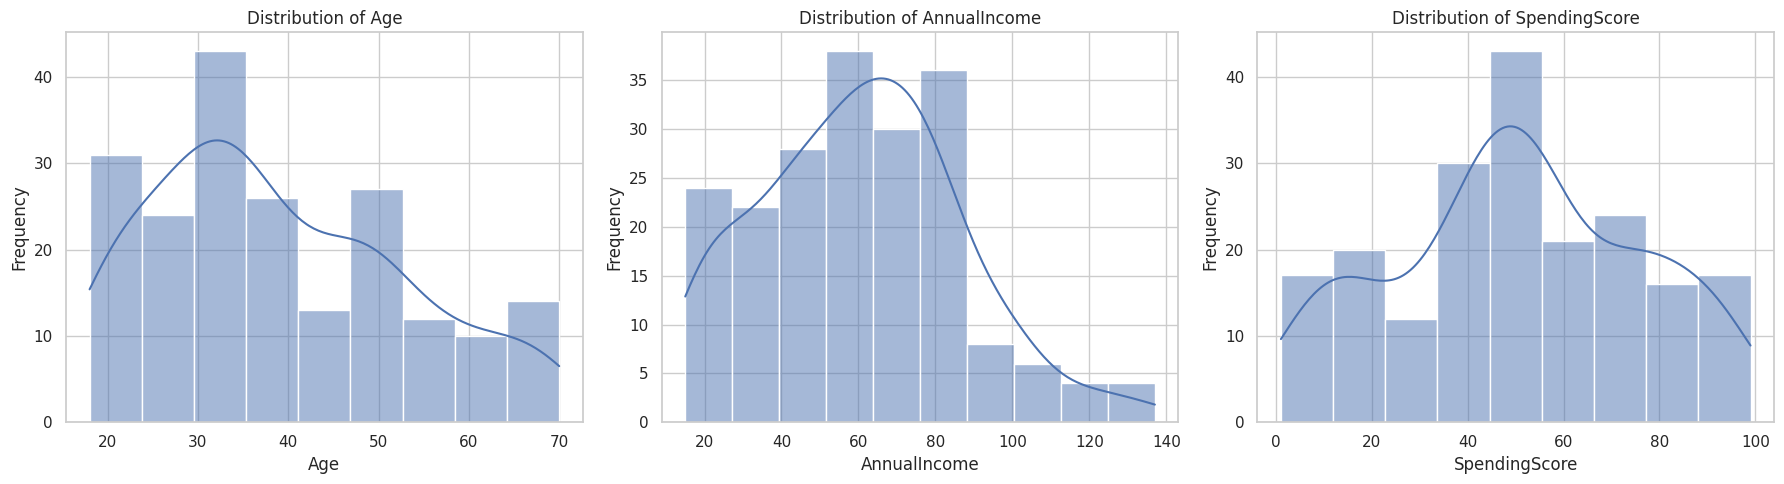

In [54]:
numerical_columns = ["Age", "AnnualIncome", "SpendingScore"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, numerical_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


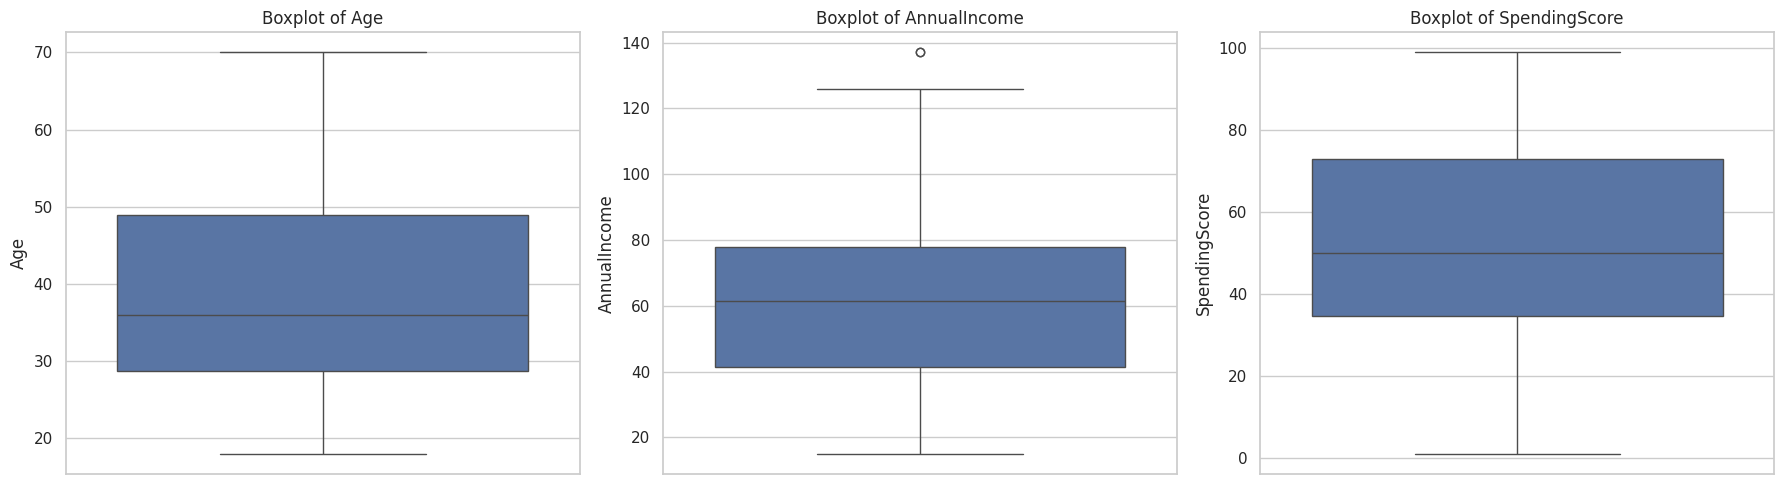

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, numerical_columns):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(f"Boxplot of {column}")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()


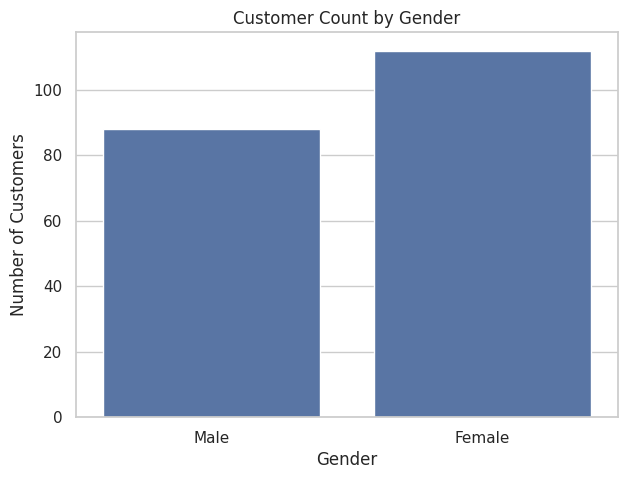

In [56]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Gender")
plt.title("Customer Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


### EDA Interpretation

- Age is concentrated mainly in the adult and middle-age ranges.
- Annual income contains several distinct income bands.
- Spending score covers low, medium and high spending behaviour.
- The gender distribution is not perfectly balanced.


## QUESTION 1.3 — Bivariate Analysis

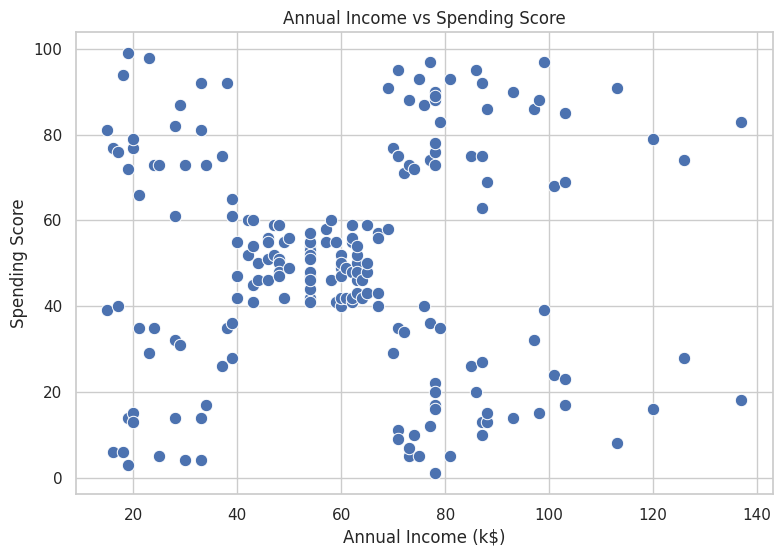

In [57]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    s=80
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()


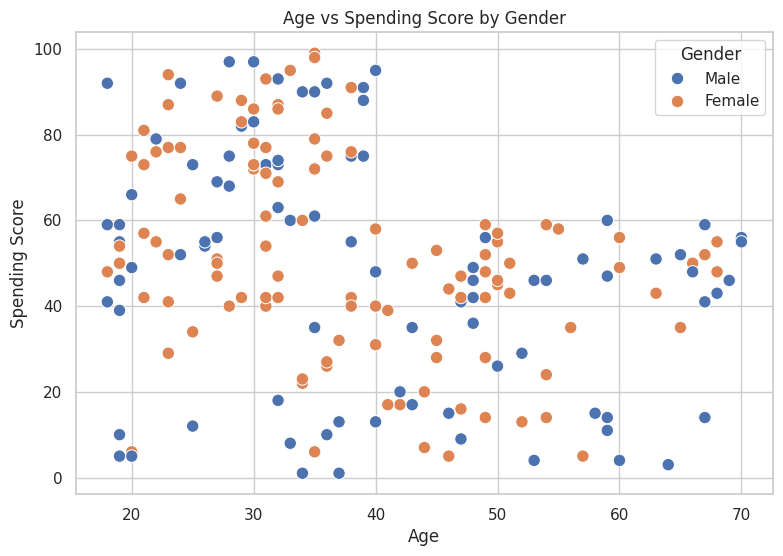

In [58]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    hue="Gender",
    s=80
)
plt.title("Age vs Spending Score by Gender")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()


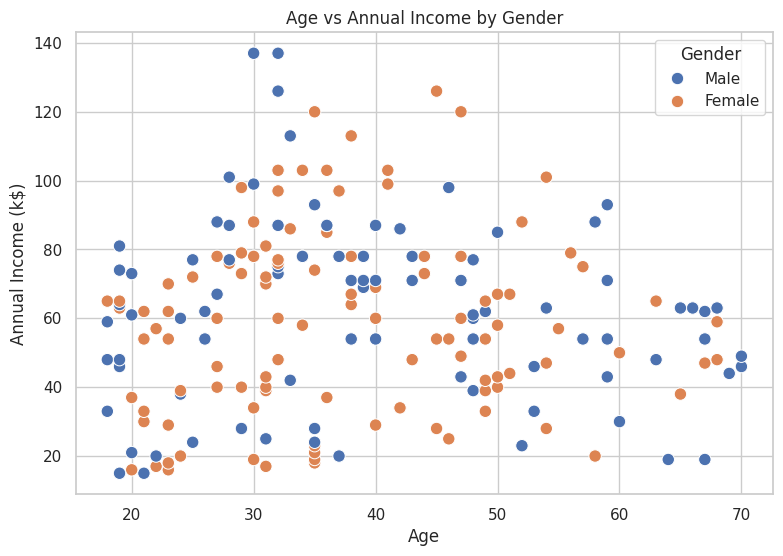

In [59]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="AnnualIncome",
    hue="Gender",
    s=80
)
plt.title("Age vs Annual Income by Gender")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()


,Age,AnnualIncome,SpendingScore
Age,1.000,-0.012,-0.327
AnnualIncome,-0.012,1.000,0.010
SpendingScore,-0.327,0.010,1.000


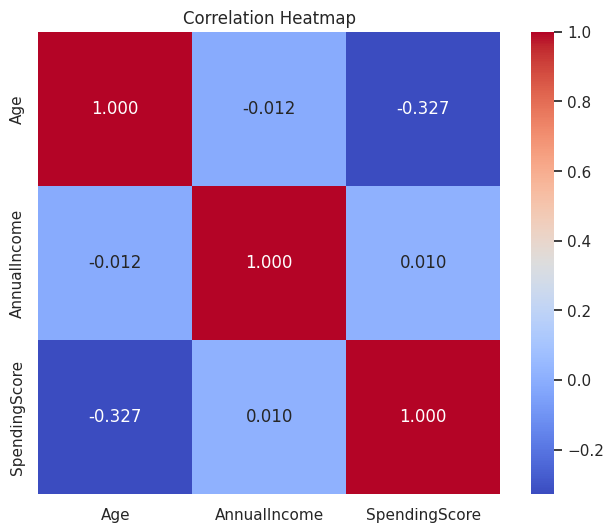

In [60]:
correlation_matrix = df[
    ["Age", "AnnualIncome", "SpendingScore"]
].corr()

display(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    square=True
)
plt.title("Correlation Heatmap")
plt.show()


### Key Visual Observation

The Annual Income versus Spending Score plot shows several visually separated
shopper groups, making it the main clustering canvas for the assignment.


## QUESTION 1.4 — Gender-Wise Summary

,Age,AnnualIncome,SpendingScore
Gender,,,
Female,38.10,59.25,51.53
Male,39.81,62.23,48.51


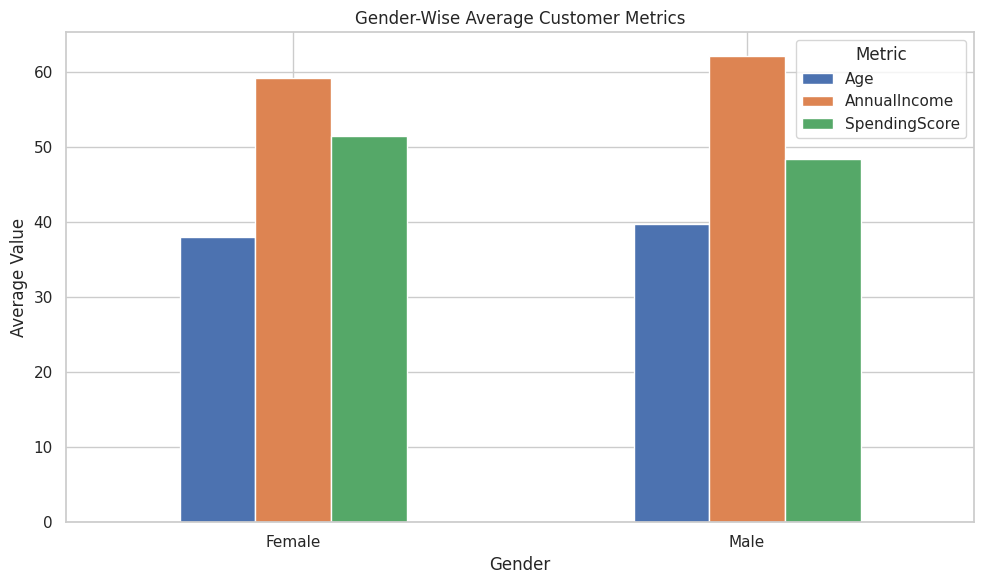

In [61]:
gender_summary = (
    df.groupby("Gender")[["Age", "AnnualIncome", "SpendingScore"]]
    .mean()
    .round(2)
)

display(gender_summary)

gender_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Gender-Wise Average Customer Metrics")
plt.xlabel("Gender")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


Female customers have a slightly lower average age and annual income than
male customers, while their average spending score is slightly higher. The
differences are relatively modest, so gender alone does not define the major
spending segments.


## STEP 2 — Feature Engineering & Preprocessing
### QUESTION 2.1 — Encode Gender

In [62]:
gender_mapping = {"Female": 0, "Male": 1}

df["Gender_enc"] = df["Gender"].map(gender_mapping)

if df["Gender_enc"].isnull().any():
    raise ValueError("Unexpected Gender value found.")

display(df[["Gender", "Gender_enc"]].head(10))
print(df["Gender_enc"].value_counts().sort_index())


,Gender,Gender_enc
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0
5,Female,0
6,Female,0
7,Female,0
8,Male,1
9,Female,0


Gender_enc
0    112
1     88
Name: count, dtype: int64


### QUESTION 2.2 — Engineer New Features

In [63]:
df["IncomeGroup"] = pd.qcut(
    df["AnnualIncome"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 25, 40, 54, np.inf],
    labels=["Young", "Adult", "Middle-Aged", "Senior"]
)

df["SpendingCategory"] = pd.cut(
    df["SpendingScore"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"]
)

print("IncomeGroup:")
display(df["IncomeGroup"].value_counts())

print("AgeGroup:")
display(df["AgeGroup"].value_counts().sort_index())

print("SpendingCategory:")
display(df["SpendingCategory"].value_counts().sort_index())


IncomeGroup:


,count
IncomeGroup,
Low,70
High,66
Medium,64


AgeGroup:


,count
AgeGroup,
Young,38
Adult,84
Middle-Aged,48
Senior,30


SpendingCategory:


,count
SpendingCategory,
Low,49
Medium,94
High,57


### QUESTION 2.3 — Select Features

In [64]:
features_2d = ["AnnualIncome", "SpendingScore"]
features_5d = ["Age", "AnnualIncome", "SpendingScore", "Gender_enc"]

X_2d = df[features_2d].copy()
X_5d = df[features_5d].copy()

print("X_2d shape:", X_2d.shape)
print("X_5d shape:", X_5d.shape)


X_2d shape: (200, 2)
X_5d shape: (200, 4)


### QUESTION 2.4 — Scale Features

In [65]:
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

scaler_5d = StandardScaler()
X_5d_scaled = scaler_5d.fit_transform(X_5d)

print("2D scaled means:", X_2d_scaled.mean(axis=0))
print("2D scaled std:", X_2d_scaled.std(axis=0))

print("4-feature experiment scaled means:", X_5d_scaled.mean(axis=0))
print("4-feature experiment scaled std:", X_5d_scaled.std(axis=0))


2D scaled means: [-2.13162821e-16 -1.46549439e-16]
2D scaled std: [1. 1.]
4-feature experiment scaled means: [-1.02140518e-16 -2.13162821e-16 -1.46549439e-16  3.10862447e-17]
4-feature experiment scaled std: [1. 1. 1. 1.]


## STEP 3 — K-MEANS CLUSTERING
### QUESTION 3.1 — Elbow Method and Silhouette Score

In [66]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(X_2d_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_2d_scaled, labels)
    )

kmeans_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "SilhouetteScore": silhouette_scores
})

display(kmeans_results.round(4))


,k,Inertia,SilhouetteScore
0,2,269.6910,0.3213
1,3,157.7040,0.4666
2,4,108.9213,0.4939
3,5,65.5684,0.5547
4,6,55.0573,0.5399
5,7,44.8648,0.5281
6,8,37.2282,0.4552
7,9,32.3923,0.4571
8,10,29.9819,0.4432


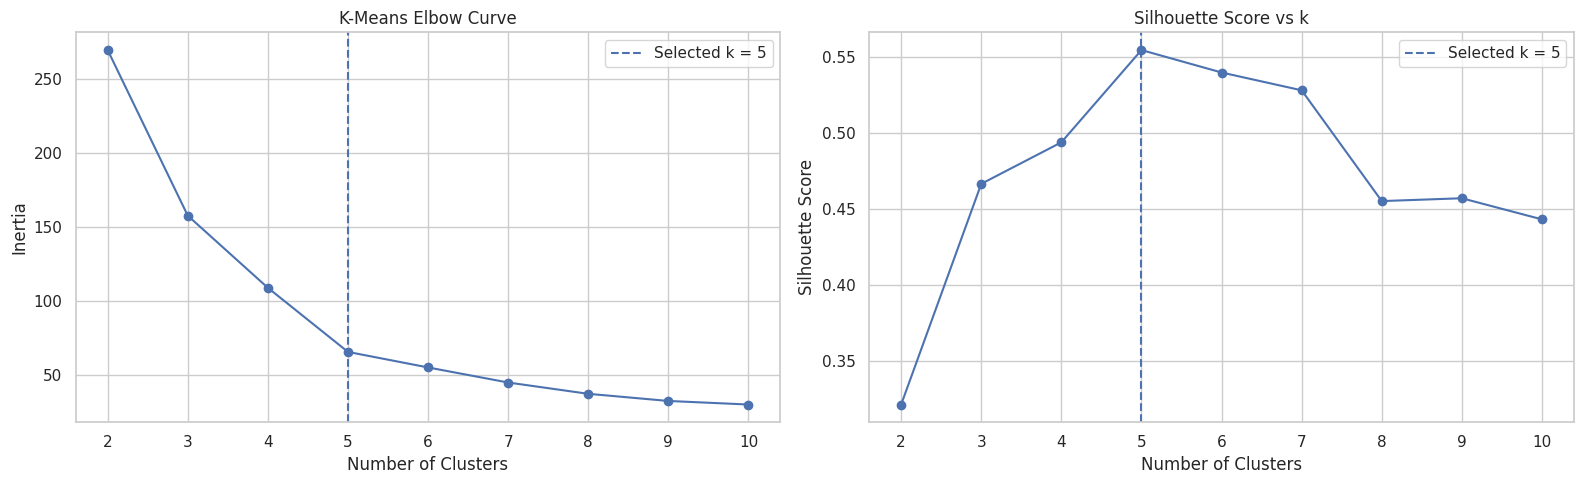

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].axvline(5, linestyle="--", label="Selected k = 5")
axes[0].set_title("K-Means Elbow Curve")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].plot(list(k_values), silhouette_scores, marker="o")
axes[1].axvline(5, linestyle="--", label="Selected k = 5")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()


### K-Means k Selection

The silhouette score reaches its maximum around k=5, and the elbow curve also
shows a substantial reduction in inertia around this point. Therefore, k=5 is
used for the final K-Means model.


### QUESTION 3.2 — Final K-Means Models

In [68]:
k_optimal = 5

kmeans_2d = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans_2d_labels = kmeans_2d.fit_predict(X_2d_scaled)
df["KMeans_Cluster"] = kmeans_2d_labels

kmeans_5d = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans_5d_labels = kmeans_5d.fit_predict(X_5d_scaled)
df["KMeans_5D_Cluster"] = kmeans_5d_labels

kmeans_2d_silhouette = silhouette_score(
    X_2d_scaled, kmeans_2d_labels
)

kmeans_5d_silhouette = silhouette_score(
    X_5d_scaled, kmeans_5d_labels
)

display(pd.DataFrame({
    "Feature Set": ["2D", "4-feature experiment"],
    "Silhouette Score": [
        kmeans_2d_silhouette,
        kmeans_5d_silhouette
    ]
}).round(4))


,Feature Set,Silhouette Score
0,2D,0.5547
1,4-feature experiment,0.3144


### QUESTION 3.3 — Visualise K-Means

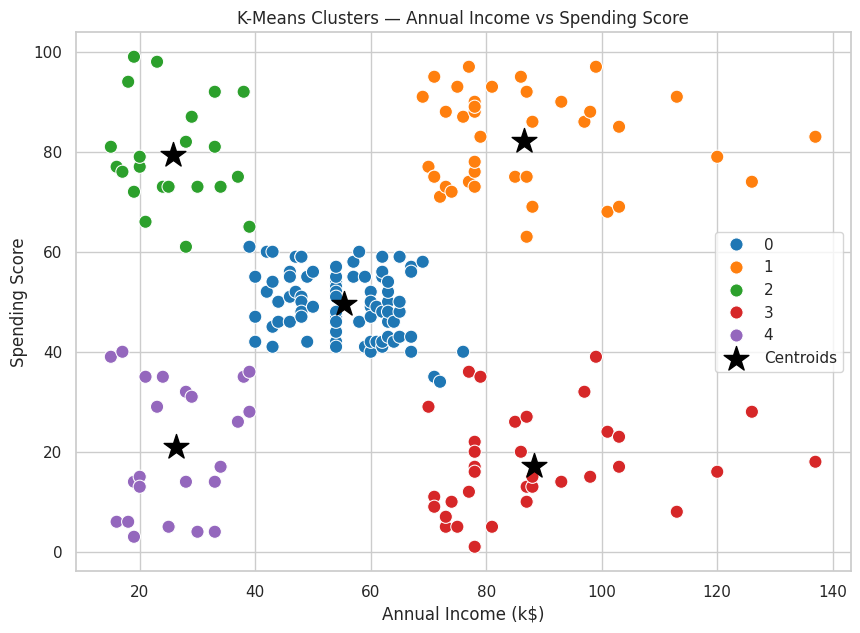

In [69]:
centroids_original = scaler_2d.inverse_transform(
    kmeans_2d.cluster_centers_
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="KMeans_Cluster",
    palette="tab10",
    s=90
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="*",
    s=350,
    c="black",
    label="Centroids"
)

plt.title("K-Means Clusters — Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()


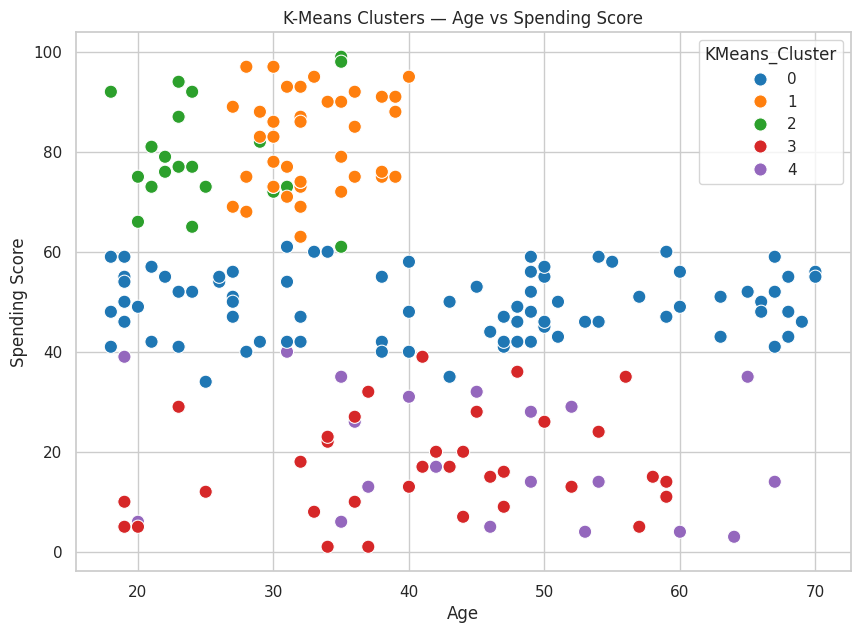

In [70]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    hue="KMeans_Cluster",
    palette="tab10",
    s=90
)

plt.title("K-Means Clusters — Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()


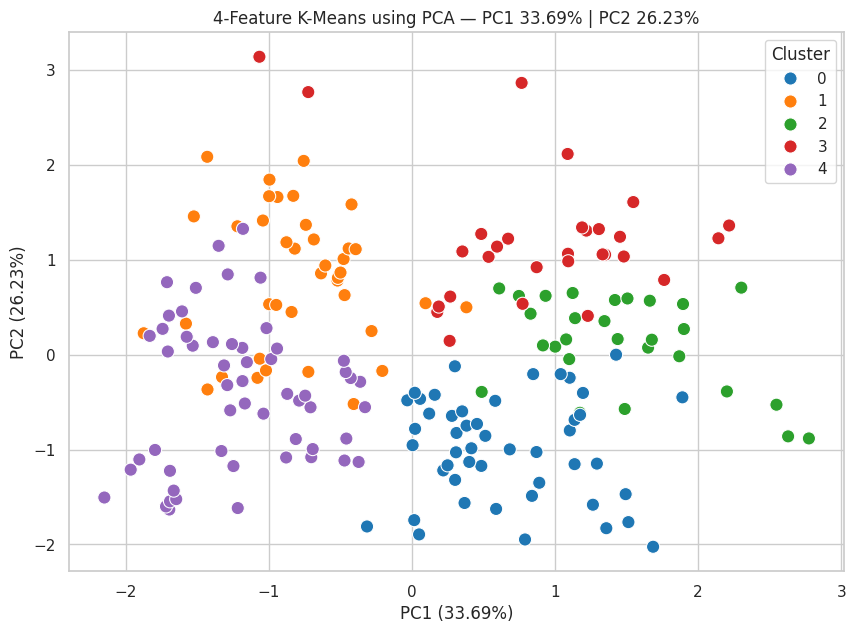

In [71]:
pca = PCA(n_components=2)
X_5d_pca = pca.fit_transform(X_5d_scaled)

pca_df = pd.DataFrame({
    "PC1": X_5d_pca[:, 0],
    "PC2": X_5d_pca[:, 1],
    "Cluster": kmeans_5d_labels
})

explained_1 = pca.explained_variance_ratio_[0] * 100
explained_2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=90
)

plt.title(
    f"4-Feature K-Means using PCA — "
    f"PC1 {explained_1:.2f}% | PC2 {explained_2:.2f}%"
)
plt.xlabel(f"PC1 ({explained_1:.2f}%)")
plt.ylabel(f"PC2 ({explained_2:.2f}%)")
plt.show()


### QUESTION 3.4 — Profile K-Means Clusters

In [72]:
kmeans_profile = (
    df.groupby("KMeans_Cluster")[
        ["Age", "AnnualIncome", "SpendingScore"]
    ]
    .mean()
    .sort_values("SpendingScore", ascending=False)
    .round(2)
)

display(kmeans_profile)

gender_split = (
    pd.crosstab(
        df["KMeans_Cluster"],
        df["Gender"],
        normalize="index"
    ) * 100
)

display(gender_split.round(2))


,Age,AnnualIncome,SpendingScore
KMeans_Cluster,,,
1,32.69,86.54,82.13
2,25.27,25.73,79.36
0,42.72,55.30,49.52
4,45.22,26.30,20.91
3,41.11,88.20,17.11


Gender,Female,Male
KMeans_Cluster,,
0,59.26,40.74
1,53.85,46.15
2,59.09,40.91
3,45.71,54.29
4,60.87,39.13


In [73]:
kmeans_personas = {}

for cluster_id, row in kmeans_profile.iterrows():
    income = row["AnnualIncome"]
    spending = row["SpendingScore"]
    age = row["Age"]

    if income >= 70 and spending >= 60:
        persona = "Big Spenders"
    elif income < 45 and spending >= 60:
        persona = "Young Aspirers"
    elif income < 45 and spending < 40:
        persona = "Budget Shoppers"
    elif income >= 70 and spending < 40:
        persona = "Careful Spenders"
    else:
        persona = "Mainstream Shoppers"

    kmeans_personas[cluster_id] = persona

df["KMeans_Persona"] = df["KMeans_Cluster"].map(kmeans_personas)

print("K-Means persona mapping:")
print(kmeans_personas)


K-Means persona mapping:
{1: 'Big Spenders', 2: 'Young Aspirers', 0: 'Mainstream Shoppers', 4: 'Budget Shoppers', 3: 'Careful Spenders'}


## STEP 4 — AGGLOMERATIVE HIERARCHICAL CLUSTERING
### QUESTION 4.1 — Dendrogram Analysis

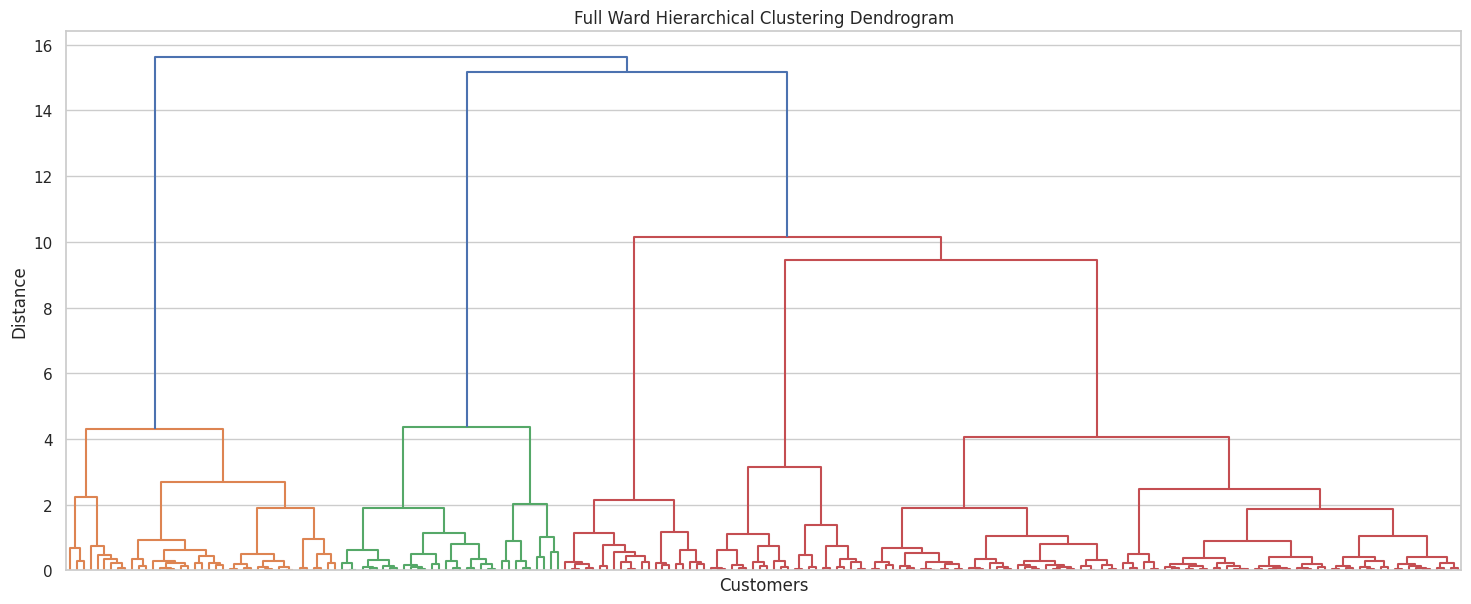

In [74]:
Z = linkage(
    X_2d_scaled,
    method="ward"
)

plt.figure(figsize=(18, 7))
dendrogram(Z, no_labels=True)
plt.title("Full Ward Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


In [75]:
merge_distances = Z[:, 2]
distance_gaps = np.diff(merge_distances)

largest_gap_index = np.argmax(distance_gaps)

lower_distance = merge_distances[largest_gap_index]
upper_distance = merge_distances[largest_gap_index + 1]

dendrogram_cut = (lower_distance + upper_distance) / 2
n_chosen = len(df) - (largest_gap_index + 1)

print("Lower merge distance:", lower_distance)
print("Upper merge distance:", upper_distance)
print("Chosen cut threshold:", dendrogram_cut)
print("Number of clusters:", n_chosen)


Lower merge distance: 4.354422154062322
Upper merge distance: 9.453352907296042
Chosen cut threshold: 6.903887530679182
Number of clusters: 5


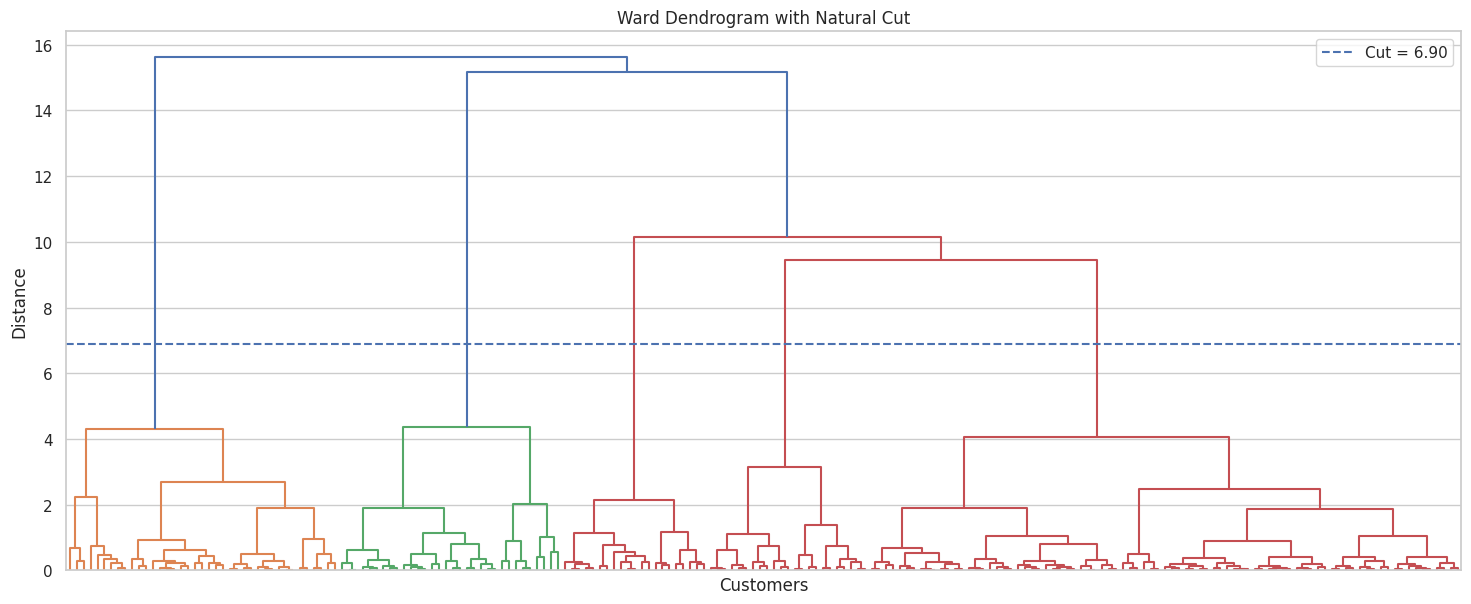

In [76]:
plt.figure(figsize=(18, 7))
dendrogram(Z, no_labels=True)

plt.axhline(
    y=dendrogram_cut,
    linestyle="--",
    label=f"Cut = {dendrogram_cut:.2f}"
)

plt.title("Ward Dendrogram with Natural Cut")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.legend()
plt.show()


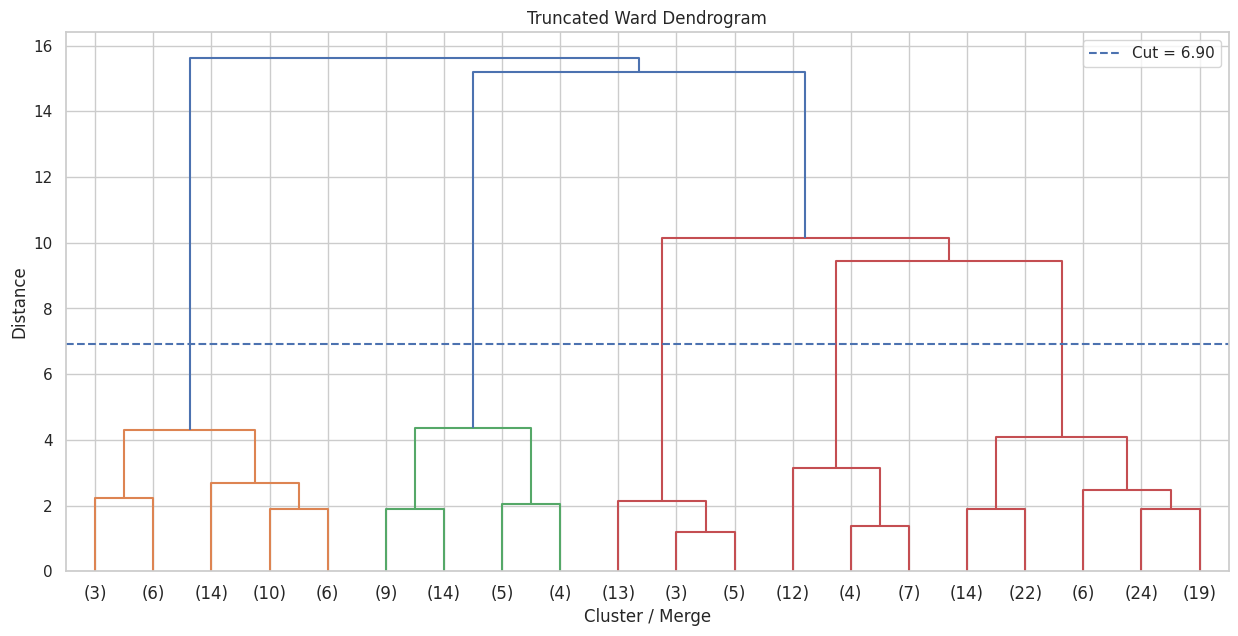

In [77]:
plt.figure(figsize=(15, 7))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)

plt.axhline(
    y=dendrogram_cut,
    linestyle="--",
    label=f"Cut = {dendrogram_cut:.2f}"
)

plt.title("Truncated Ward Dendrogram")
plt.xlabel("Cluster / Merge")
plt.ylabel("Distance")
plt.legend()
plt.show()


### QUESTION 4.2 — Compare Linkage Methods

In [78]:
linkage_methods = ["ward", "complete", "average"]
agglomerative_results = []

for method in linkage_methods:
    model = AgglomerativeClustering(
        n_clusters=n_chosen,
        linkage=method
    )

    labels = model.fit_predict(X_2d_scaled)

    agglomerative_results.append({
        "Linkage": method,
        "Silhouette Score": silhouette_score(
            X_2d_scaled, labels
        )
    })

agg_comparison = pd.DataFrame(agglomerative_results)
display(
    agg_comparison
    .sort_values("Silhouette Score", ascending=False)
    .round(4)
)


,Linkage,Silhouette Score
0,ward,0.5538
1,complete,0.5531
2,average,0.4794


In [79]:
best_linkage = (
    agg_comparison
    .sort_values("Silhouette Score", ascending=False)
    .iloc[0]["Linkage"]
)

agg_model = AgglomerativeClustering(
    n_clusters=n_chosen,
    linkage=best_linkage
)

agg_labels = agg_model.fit_predict(X_2d_scaled)
df["Agg_Cluster"] = agg_labels

print("Selected linkage:", best_linkage)


Selected linkage: ward


### QUESTION 4.3 — Visualise and Profile Hierarchical Clusters

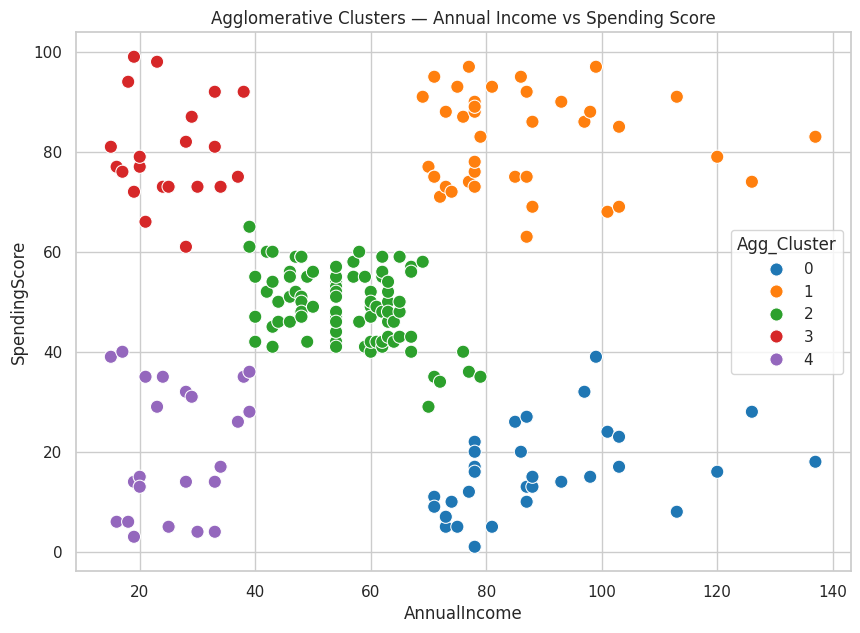

In [80]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="Agg_Cluster",
    palette="tab10",
    s=90
)
plt.title("Agglomerative Clusters — Annual Income vs Spending Score")
plt.show()


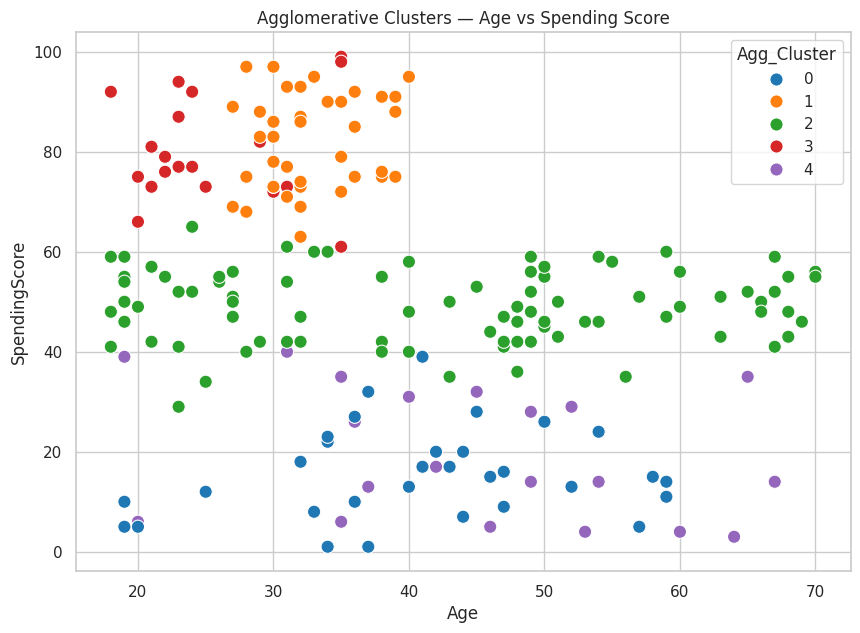

In [81]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    hue="Agg_Cluster",
    palette="tab10",
    s=90
)
plt.title("Agglomerative Clusters — Age vs Spending Score")
plt.show()


In [82]:
agg_profile = (
    df.groupby("Agg_Cluster")[
        ["Age", "AnnualIncome", "SpendingScore"]
    ]
    .mean()
    .round(2)
)

display(agg_profile)


,Age,AnnualIncome,SpendingScore
Agg_Cluster,,,
0,41.00,89.41,15.59
1,32.69,86.54,82.13
2,42.48,55.81,49.13
3,25.33,25.10,80.05
4,45.22,26.30,20.91


### K-Means vs Hierarchical Agreement

In [83]:
direct_agreement = (
    df["KMeans_Cluster"] == df["Agg_Cluster"]
).mean() * 100

contingency = pd.crosstab(
    df["KMeans_Cluster"],
    df["Agg_Cluster"]
)

row_ind, col_ind = linear_sum_assignment(
    -contingency.values
)

matched_customers = contingency.values[
    row_ind,
    col_ind
].sum()

aligned_agreement = (
    matched_customers / len(df)
) * 100

print(f"Direct label agreement: {direct_agreement:.2f}%")
print(f"Label-aligned agreement: {aligned_agreement:.2f}%")


Direct label agreement: 31.50%
Label-aligned agreement: 98.00%


## STEP 5 — DBSCAN CLUSTERING
### QUESTION 5.1 — k-NN Distance Plot

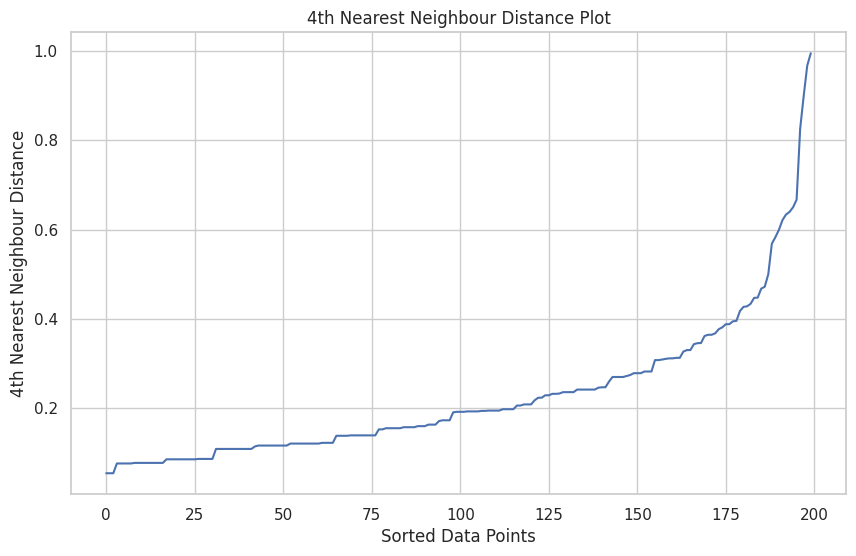

In [84]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors.fit(X_2d_scaled)

distances, indices = neighbors.kneighbors(X_2d_scaled)

fourth_neighbor_distances = np.sort(distances[:, 3])

plt.figure(figsize=(10, 6))
plt.plot(
    range(len(fourth_neighbor_distances)),
    fourth_neighbor_distances
)

plt.title("4th Nearest Neighbour Distance Plot")
plt.xlabel("Sorted Data Points")
plt.ylabel("4th Nearest Neighbour Distance")
plt.show()


The k-NN curve is used to identify a sharp bend. The assignment's required
DBSCAN grid is also used below to validate the final epsilon and min_samples.


### QUESTION 5.2 — Initial DBSCAN

In [85]:
optimal_eps_initial = 0.4

dbscan_initial = DBSCAN(
    eps=optimal_eps_initial,
    min_samples=4,
    metric="euclidean"
)

initial_labels = dbscan_initial.fit_predict(X_2d_scaled)

df["DBSCAN_Initial_Cluster"] = initial_labels

initial_cluster_count = len(
    set(initial_labels) - {-1}
)

initial_noise_count = (initial_labels == -1).sum()
initial_noise_percentage = (
    initial_noise_count / len(df)
) * 100

print("Initial DBSCAN clusters:", initial_cluster_count)
print("Initial noise points:", initial_noise_count)
print(f"Initial noise percentage: {initial_noise_percentage:.2f}%")


Initial DBSCAN clusters: 3
Initial noise points: 14
Initial noise percentage: 7.00%


### QUESTION 5.3 — DBSCAN Hyperparameter Grid

In [86]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 7, 10]

dbscan_grid_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )

        labels = model.fit_predict(X_2d_scaled)

        noise_mask = labels == -1
        noise_percentage = noise_mask.mean() * 100
        cluster_count = len(set(labels) - {-1})

        score = np.nan

        if cluster_count >= 2 and noise_percentage < 30:
            non_noise = ~noise_mask

            score = silhouette_score(
                X_2d_scaled[non_noise],
                labels[non_noise]
            )

        dbscan_grid_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": cluster_count,
            "noise_percentage": noise_percentage,
            "silhouette_score": score
        })

dbscan_grid_df = pd.DataFrame(dbscan_grid_results)
display(dbscan_grid_df.round(4))


,eps,min_samples,clusters,noise_percentage,silhouette_score
0,0.2,3,13,22.0,0.4697
1,0.2,4,5,36.5,NaN
2,0.2,5,7,38.5,NaN
3,0.2,7,4,50.0,NaN
4,0.2,10,1,64.5,NaN
5,0.4,3,4,5.0,0.3954
6,0.4,4,3,7.0,0.4576
7,0.4,5,4,7.5,0.4781
8,0.4,7,4,10.0,0.4946
9,0.4,10,4,25.5,0.5972


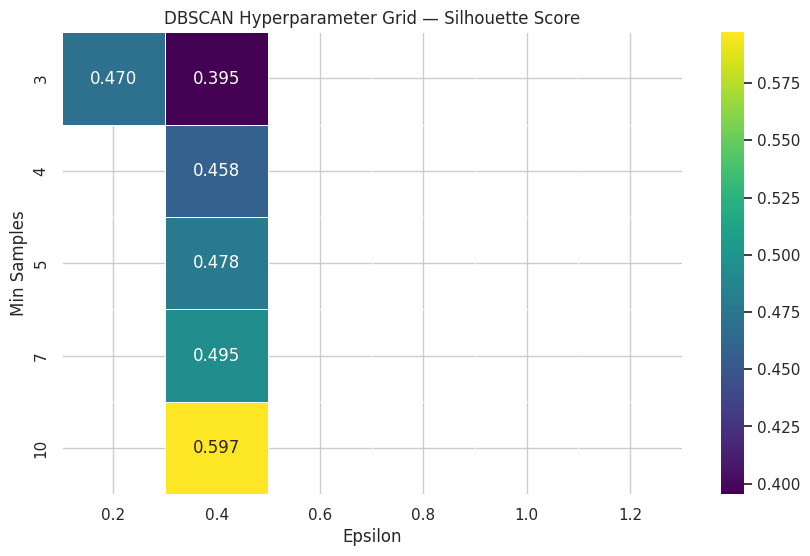

In [87]:
heatmap_data = dbscan_grid_df.pivot(
    index="min_samples",
    columns="eps",
    values="silhouette_score"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5
)

plt.title("DBSCAN Hyperparameter Grid — Silhouette Score")
plt.xlabel("Epsilon")
plt.ylabel("Min Samples")
plt.show()


In [88]:
valid_dbscan_results = dbscan_grid_df.dropna(
    subset=["silhouette_score"]
)

best_dbscan_row = valid_dbscan_results.loc[
    valid_dbscan_results["silhouette_score"].idxmax()
]

optimal_eps = float(best_dbscan_row["eps"])
optimal_min_samples = int(best_dbscan_row["min_samples"])

print("Optimal eps:", optimal_eps)
print("Optimal min_samples:", optimal_min_samples)
print(
    "Best silhouette:",
    round(best_dbscan_row["silhouette_score"], 4)
)


Optimal eps: 0.4
Optimal min_samples: 10
Best silhouette: 0.5972


### Final DBSCAN Model

In [89]:
dbscan_model = DBSCAN(
    eps=optimal_eps,
    min_samples=optimal_min_samples,
    metric="euclidean"
)

dbscan_labels = dbscan_model.fit_predict(X_2d_scaled)
df["DBSCAN_Cluster"] = dbscan_labels

dbscan_cluster_count = len(set(dbscan_labels) - {-1})
dbscan_noise_count = (dbscan_labels == -1).sum()
dbscan_noise_percentage = (
    dbscan_noise_count / len(df)
) * 100

print("DBSCAN clusters:", dbscan_cluster_count)
print("Noise points:", dbscan_noise_count)
print(f"Noise percentage: {dbscan_noise_percentage:.2f}%")


DBSCAN clusters: 4
Noise points: 51
Noise percentage: 25.50%


### QUESTION 5.4 — Visualise DBSCAN

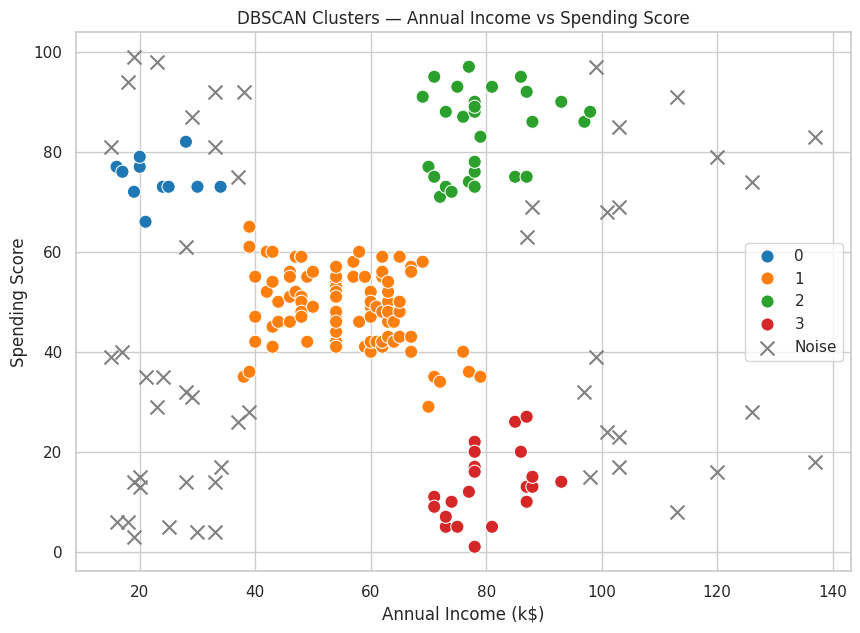

In [90]:
normal_mask = df["DBSCAN_Cluster"] != -1
noise_mask = df["DBSCAN_Cluster"] == -1

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df[normal_mask],
    x="AnnualIncome",
    y="SpendingScore",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=90
)

plt.scatter(
    df.loc[noise_mask, "AnnualIncome"],
    df.loc[noise_mask, "SpendingScore"],
    marker="x",
    s=100,
    c="grey",
    label="Noise"
)

plt.title("DBSCAN Clusters — Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()


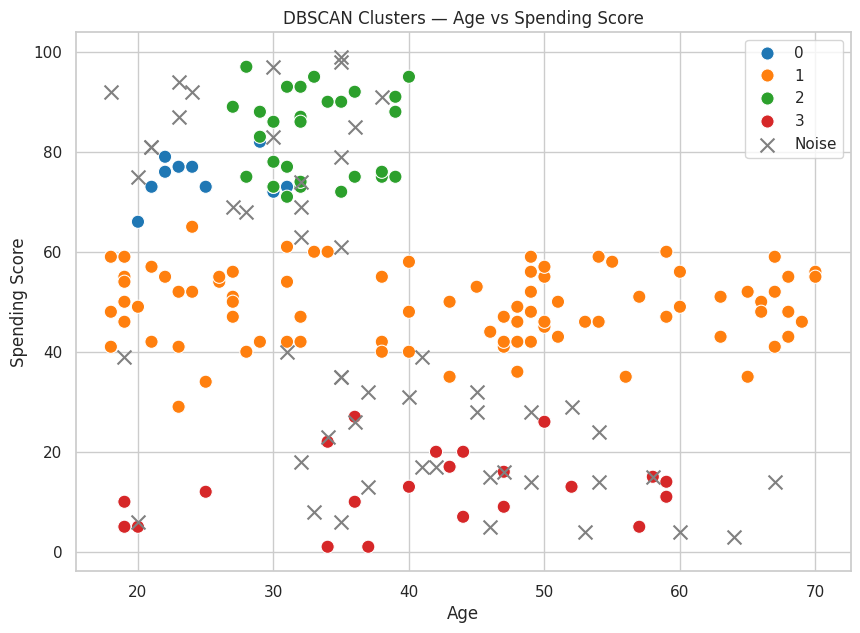

In [91]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df[normal_mask],
    x="Age",
    y="SpendingScore",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=90
)

plt.scatter(
    df.loc[noise_mask, "Age"],
    df.loc[noise_mask, "SpendingScore"],
    marker="x",
    s=100,
    c="grey",
    label="Noise"
)

plt.title("DBSCAN Clusters — Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.legend()
plt.show()


In [92]:
dbscan_profile = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[
        ["Age", "AnnualIncome", "SpendingScore"]
    ]
    .mean()
    .sort_values("SpendingScore", ascending=False)
    .round(2)
)

display(dbscan_profile)

noise_profile = (
    df[df["DBSCAN_Cluster"] == -1][
        ["Age", "AnnualIncome", "SpendingScore"]
    ]
    .mean()
    .round(2)
)

print("Noise profile:")
display(noise_profile)


,Age,AnnualIncome,SpendingScore
DBSCAN_Cluster,,,
2,32.93,79.24,83.62
0,25.18,23.09,74.64
1,42.80,55.41,48.82
3,41.00,80.18,12.68


Noise profile:


,0
Age,37.49
AnnualIncome,58.33
SpendingScore,44.47


### DBSCAN Noise Interpretation

Noise points should not automatically be interpreted as extreme outliers.
Their profile can represent customers who sit between the dense shopper
segments and do not meet DBSCAN's density requirements.


## STEP 6 — Algorithm Comparison & Business Interpretation
### QUESTION 6.1 — Internal Metrics Comparison

In [93]:
kmeans_sil = silhouette_score(X_2d_scaled, kmeans_2d_labels)
kmeans_db = davies_bouldin_score(X_2d_scaled, kmeans_2d_labels)
kmeans_ch = calinski_harabasz_score(X_2d_scaled, kmeans_2d_labels)

agg_sil = silhouette_score(X_2d_scaled, agg_labels)
agg_db = davies_bouldin_score(X_2d_scaled, agg_labels)
agg_ch = calinski_harabasz_score(X_2d_scaled, agg_labels)

dbscan_non_noise = dbscan_labels != -1

dbscan_sil = silhouette_score(
    X_2d_scaled[dbscan_non_noise],
    dbscan_labels[dbscan_non_noise]
)

dbscan_db = davies_bouldin_score(
    X_2d_scaled[dbscan_non_noise],
    dbscan_labels[dbscan_non_noise]
)

dbscan_ch = calinski_harabasz_score(
    X_2d_scaled[dbscan_non_noise],
    dbscan_labels[dbscan_non_noise]
)

comparison_table = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative", "DBSCAN"],
    "Final Hyperparameters": [
        "k=5, k-means++, n_init=20",
        f"n_clusters={n_chosen}, linkage={best_linkage}",
        f"eps={optimal_eps}, min_samples={optimal_min_samples}"
    ],
    "Clusters": [
        len(set(kmeans_2d_labels)),
        len(set(agg_labels)),
        dbscan_cluster_count
    ],
    "Silhouette Score": [
        kmeans_sil,
        agg_sil,
        dbscan_sil
    ],
    "Davies-Bouldin Index": [
        kmeans_db,
        agg_db,
        dbscan_db
    ],
    "Calinski-Harabasz Index": [
        kmeans_ch,
        agg_ch,
        dbscan_ch
    ],
    "Noise %": [
        0,
        0,
        dbscan_noise_percentage
    ]
})

display(comparison_table.round(4))


,Algorithm,Final Hyperparameters,Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Noise %
0,K-Means,"k=5, k-means++, n_init=20",5,0.5547,0.5722,248.6493,0.0
1,Agglomerative,"n_clusters=5, linkage=ward",5,0.5538,0.5779,244.4103,0.0
2,DBSCAN,"eps=0.4, min_samples=10",4,0.5972,0.4734,263.6118,25.5


### QUESTION 6.2 — K-Means Stability Check

In [94]:
stability_seeds = [0, 7, 21, 42, 99]
stability_results = []

for seed in stability_seeds:
    model = KMeans(
        n_clusters=k_optimal,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=seed
    )

    labels = model.fit_predict(X_2d_scaled)

    stability_results.append({
        "Random State": seed,
        "Silhouette Score": silhouette_score(
            X_2d_scaled,
            labels
        )
    })

stability_df = pd.DataFrame(stability_results)

display(stability_df.round(4))

print(
    f"Mean ± Std: "
    f"{stability_df['Silhouette Score'].mean():.4f} ± "
    f"{stability_df['Silhouette Score'].std():.4f}"
)


,Random State,Silhouette Score
0,0,0.5547
1,7,0.5547
2,21,0.5547
3,42,0.5547
4,99,0.5547


Mean ± Std: 0.5547 ± 0.0000


## STEP 7 — Pipeline, Deployment & GitHub
### QUESTION 7.1 — Save Final Pipeline

In [95]:
joblib.dump(
    scaler_2d,
    "mall_scaler.pkl"
)

joblib.dump(
    dbscan_model,
    "mall_segmentation_model.pkl"
)

print("Saved:")
print("mall_scaler.pkl")
print("mall_segmentation_model.pkl")


Saved:
mall_scaler.pkl
mall_segmentation_model.pkl
